In [4]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.insert(0, '/home/kat/Repos/SALSA/')

# # # # # # # # # # # 
# tag = '2022042420_a05_2000n_train_32neigh_mindist0pt1'

# tag = '2022041804_04_2000n_test_32neigh_mindist0pt1'
# tag = '2022041804_04_12000n_extended_32neigh_mindist0pt1'
# tag = '2022041807_a03_2000n_test_32neigh_mindist0pt1'
# tag = '2022041807_a03_12000n_extended_32neigh_mindist0pt1'
tag = '2022041809_a04_2000n_test_32neigh_mindist0pt1'
# tag = '2022041809_a04_12000n_extended_32neigh_mindist0pt1'
# # # # # # # # # # # 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import pandas as pd
from rdkit.Chem import PandasTools
from utilities.fp_utils import get_fps_in_parallel

df = pd.read_csv(f'/home/kat/Repos/SALSA/results/umap_dfs/{tag}.csv')
PandasTools.AddMoleculeColumnToFrame(df,'Smiles','Mol',includeFingerprints=False)
df = df[["Smiles","Mol","Label","Atype","x","y"]]
df_show = df[["Smiles","Label","Atype","x","y"]]

In [20]:
fps = get_fps_in_parallel(df.Smiles, 'morgan')

In [21]:
fps[0]

array([0, 1, 0, ..., 0, 0, 0], dtype=int32)

In [22]:
from datetime import datetime
today = datetime.today().strftime('%Y%m%d%H')
v = 'blmorgan'
tag = f'{today}_{v}'
tag

'2022042709_blmorgan'

In [23]:
fps = np.stack(fps)
fps.shape

(12000, 1024)

Tag is 2022042709_blmorgan_2000n_test_32neigh_mindist0pt1!
Saved smiles and coords to /home/kat/Repos/SALSA/results/umap_dfs/2022042709_blmorgan_2000n_test_32neigh_mindist0pt1.csv!
Saved umap plot to /home/kat/Repos/SALSA/results/umap_figs/2022042709_blmorgan_2000n_test_32neigh_mindist0pt1.png!


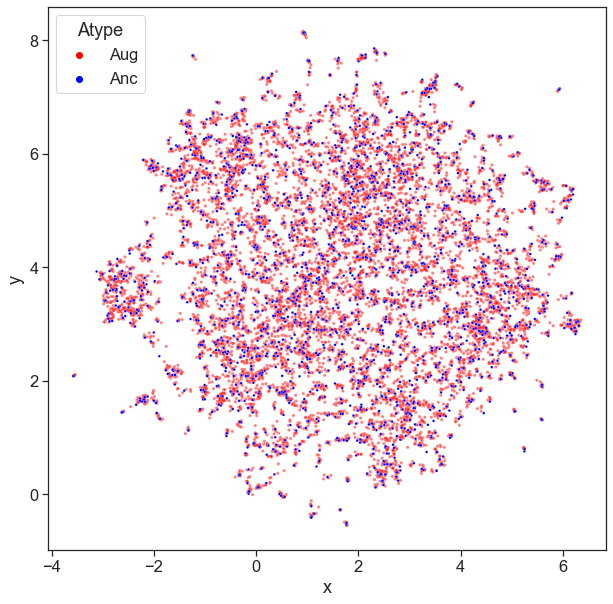

In [24]:
from eval_functions import *

which_test, test_ood, test_extended = ('01', False, False)
which_train = '01'
samp_size = 2000

tag_emb = get_umap_tag(tag, which_test, test_ood, test_extended, samp_size)
df_umap = get_umap_coords(tag_emb, df, fps, n_neighs=32, min_dist=0.1, 
                          save_coords=True, save_plot=True, show_plot=True)

In [ ]:
tag = '2022041809_a04'
param_list = [('train', False, False), # train set (2000*6)
              ('01', False, False),    # test set (2000*6)
              ('01', True, False),     # ood set (2000*6)
              ('01', False, True)]     # extended set (12000)

for params in param_list:
    
    which_test, test_ood, test_extended = params

    which_train = '01'
    samp_size = 2000
    if test_extended:
        samp_size = 12000
    n_epochs = 30

    eval_bs = 6
    use_cuda = True
    empty_cuda = True
    cuda_ids = [0,1,2,3]

    df, latents = get_df_and_latents(tag, which_train, which_test, test_ood, test_extended,
                                     samp_size, eval_bs, n_epochs, use_cuda, empty_cuda, cuda_ids)
    tag_emb = get_umap_tag(tag, which_test, test_ood, test_extended, samp_size)
    df_umap = get_umap_coords(tag_emb, df, latents, n_neighs=32, min_dist=0.1, 
                              save_coords=True, save_plot=True, show_plot=True)